In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from aquarel import load_theme
from pathlib import Path
import seaborn as sns
import scipy.stats as stats

FE_DF_PATH = Path("../data/processed/ames_housing_featured_engineered.parquet")
fe_df = pd.read_parquet(FE_DF_PATH)

In [2]:
# look at the featured engineered dataset
fe_df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Was Remodelled,Remod Age,Total Bathrooms,Total Porch SF,Overall Qual Gr Liv,Total Rooms Gr Liv,Built Decade,Has Pool,Has Fireplace,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,None,IR1,Lvl,...,0,50,2.0,272,9936,11592,1960,0,1,215000
1,2,526350040,20,RH,80.0,11622,Pave,None,Reg,Lvl,...,0,49,1.0,260,4480,4480,1960,0,0,105000
2,3,526351010,20,RL,81.0,14267,Pave,None,IR1,Lvl,...,0,52,1.5,429,7974,7974,1950,0,0,172000
3,4,526353030,20,RL,93.0,11160,Pave,None,Reg,Lvl,...,0,42,3.5,0,14770,16880,1960,0,1,244000
4,5,527105010,60,RL,74.0,13830,Pave,None,IR1,Lvl,...,1,12,2.5,246,8145,9774,1990,0,1,189900


In [3]:
# shape
fe_df.shape

(2925, 92)

In [4]:
# info about the df
fe_df.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 2925 entries, 0 to 2924
Data columns (total 92 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   Order                2925 non-null   int64   
 1   PID                  2925 non-null   int64   
 2   MS SubClass          2925 non-null   int64   
 3   MS Zoning            2925 non-null   category
 4   Lot Frontage         2925 non-null   float64 
 5   Lot Area             2925 non-null   int64   
 6   Street               2925 non-null   category
 7   Alley                2925 non-null   category
 8   Lot Shape            2925 non-null   category
 9   Land Contour         2925 non-null   category
 10  Utilities            2925 non-null   category
 11  Lot Config           2925 non-null   category
 12  Land Slope           2925 non-null   category
 13  Neighborhood         2925 non-null   category
 14  Condition 1          2925 non-null   category
 15  Condition 2          2925 non-nu

## Exploratory Data Analysis

In [5]:
# basic stats
fe_df.describe(include="number")

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Was Remodelled,Remod Age,Total Bathrooms,Total Porch SF,Overall Qual Gr Liv,Total Rooms Gr Liv,Built Decade,Has Pool,Has Fireplace,SalePrice
count,2925.000000,2.925000e+03,2925.000000,2925.000000,2925.000000,2925.000000,2925.000000,2925.000000,2925.000000,2925.000000,...,2925.000000,2925.000000,2925.000000,2925.000000,2925.000000,2925.000000,2925.000000,2925.000000,2925.000000,2925.000000
mean,1464.794530,7.143931e+08,57.396581,69.298462,10103.583590,6.088205,5.563761,1971.302906,1984.234188,99.918632,...,0.463932,23.557265,2.214359,182.236239,9480.832821,10225.286154,1966.782906,0.003761,0.513846,180411.574701
std,846.441706,1.887274e+08,42.668752,21.131691,7781.999124,1.402953,1.112262,30.242474,20.861774,175.566155,...,0.498783,20.859471,0.803463,158.817189,4731.627398,5771.566942,29.666564,0.061219,0.499894,78554.857286
min,1.000000,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,...,0.000000,-1.000000,1.000000,0.000000,334.000000,668.000000,1870.000000,0.000000,0.000000,12789.000000
25%,732.000000,5.284770e+08,20.000000,60.000000,7438.000000,5.000000,5.000000,1954.000000,1965.000000,0.000000,...,0.000000,4.000000,1.500000,48.000000,5915.000000,6240.000000,1950.000000,0.000000,0.000000,129500.000000
50%,1463.000000,5.354532e+08,50.000000,70.000000,9428.000000,6.000000,5.000000,1973.000000,1993.000000,0.000000,...,0.000000,15.000000,2.000000,164.000000,8640.000000,8874.000000,1970.000000,0.000000,1.000000,160000.000000
75%,2199.000000,9.071801e+08,70.000000,80.000000,11515.000000,7.000000,6.000000,2001.000000,2004.000000,162.000000,...,1.000000,43.000000,2.500000,266.000000,11958.000000,12530.000000,2000.000000,0.000000,1.000000,213500.000000
max,2930.000000,1.007100e+09,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,...,1.000000,60.000000,7.000000,1424.000000,36270.000000,47530.000000,2010.000000,1.000000,1.000000,625000.000000


In [6]:
# set matplotlib params and theme
plt.rcParams.update({
    "axes.titlesize": 18,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.labelsize": 14,
})

theme = load_theme("arctic_light").set_grid(alpha=0.3).set_font(family="monospace")
theme.apply()

### Target Variable Analysis

How is SalePrice distributed? Is it right-skewed?

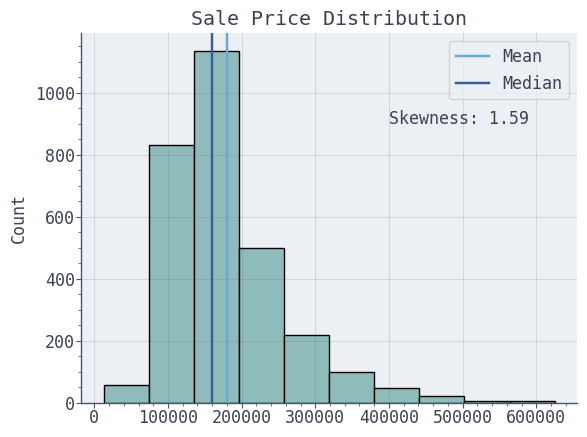

In [7]:
sale_price_stats_df = fe_df.SalePrice.agg(["mean", "median", "skew"]).round(2).to_frame()

plt.hist(fe_df.SalePrice, edgecolor="black")
plt.title("Sale Price Distribution")
plt.text(400000, 900, s=f"Skewness: {sale_price_stats_df.iloc[2, 0]}")
plt.axvline(sale_price_stats_df.iloc[0, 0], color="#65aacf", label="Mean")
plt.axvline(sale_price_stats_df.iloc[1, 0], color="#335f9e", label="Median")
plt.ylabel("Count")
plt.legend()
plt.show()

### Numerical Features Analysis

Is Gross Living Area normally distributed? Are there outliers?

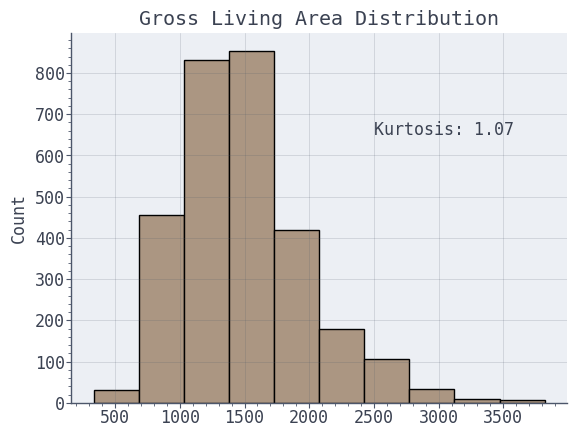

In [8]:
gr_liv_area_kurt = round(stats.kurtosis(fe_df["Gr Liv Area"]), ndigits=2)

plt.hist(fe_df["Gr Liv Area"], edgecolor="black", color="#ab9682")
plt.title("Gross Living Area Distribution")
plt.ylabel("Count")
plt.text(2500, 650, s=f"Kurtosis: {gr_liv_area_kurt}")
plt.show()

What about years? Were houses built a long time ago or more recently? Also, are remodels common?

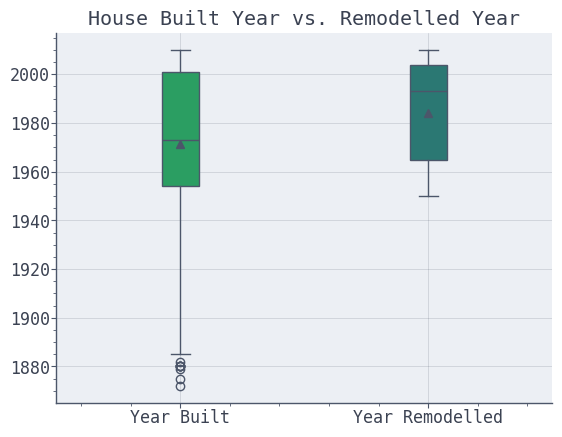

In [9]:
years_colors = ["#2b9e62", "#2b7873"]

years_boxplot = plt.boxplot([fe_df["Year Built"], fe_df["Year Remod/Add"]], patch_artist=True, tick_labels=["Year Built", "Year Remodelled"], 
                            showmeans=True)

for body, color in zip(years_boxplot["boxes"], years_colors):
    body.set_facecolor(color)
plt.title("House Built Year vs. Remodelled Year")
plt.show()

### Categorical Analysis

Are most houses excellent in terms of quality? Are there poor ones as well?

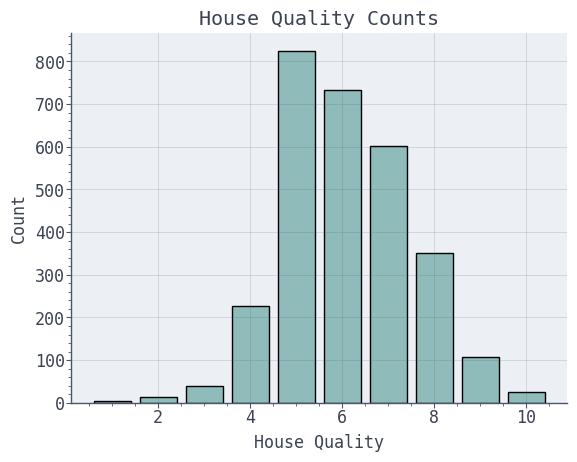

In [10]:
house_quality_df = fe_df["Overall Qual"].value_counts().to_frame()

plt.bar(house_quality_df.index, house_quality_df.values.flatten(), edgecolor="black")
plt.xlabel("House Quality")
plt.ylabel("Count")
plt.title("House Quality Counts")
plt.show()

What's the condition instead?

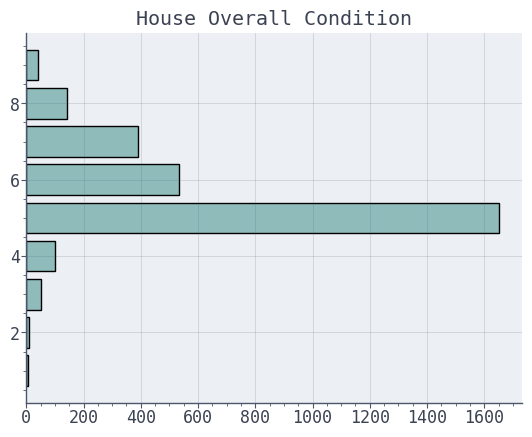

In [11]:
overall_cond_df = fe_df["Overall Cond"].value_counts().to_frame()

plt.barh(overall_cond_df.index, overall_cond_df.values.flatten(), edgecolor="black")
plt.title("House Overall Condition")
plt.show()

### Target Relationships

Does higher house quality mean higher sale price?

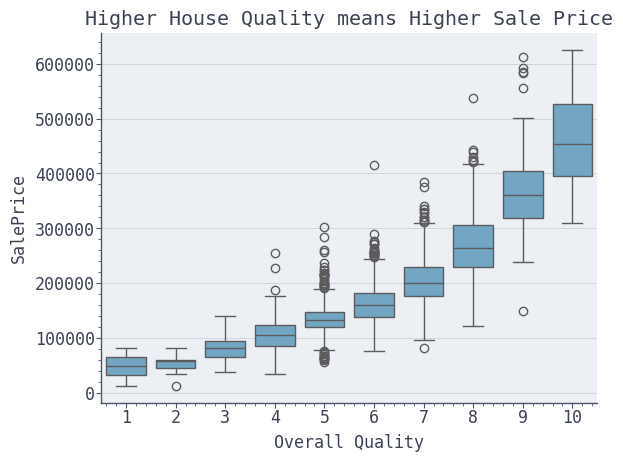

In [12]:
sns.boxplot(data=fe_df, x="Overall Qual", y="SalePrice", color="#65aacf")
plt.xlabel("Overall Quality")
plt.title("Higher House Quality means Higher Sale Price")
plt.show()

Are older homes sold cheaper?

In [13]:
# let's the the max. and min.
min_year_built, max_year_built = fe_df["Year Built"].min(), fe_df["Year Built"].max()

print(f"Min. Year Built: {min_year_built}")
print(f"Max. Year Built: {max_year_built}")

Min. Year Built: 1872
Max. Year Built: 2010


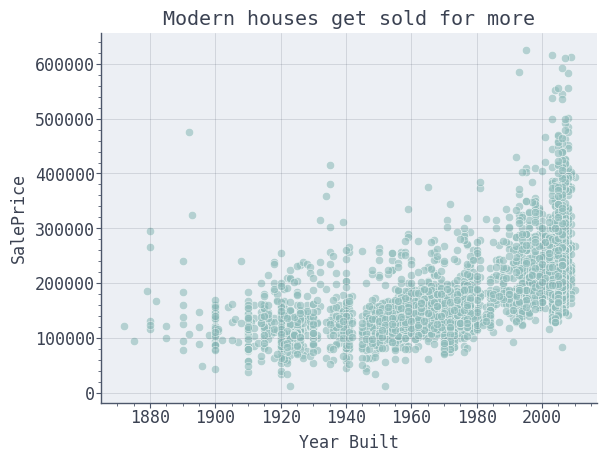

In [14]:
sns.scatterplot(data=fe_df, x="Year Built", y="SalePrice", alpha=0.6)
plt.title("Modern houses get sold for more")
plt.show()

### Correlation Analysis

Are there numeric features that are more correlated with sale price?

In [15]:
numeric_corrs = fe_df.corr(method="pearson", numeric_only=True)["SalePrice"].round(1).sort_values(ascending=False)

# show most important features
numeric_corrs.head(15)

SalePrice              1.0
Overall Qual Gr Liv    0.9
Overall Qual           0.8
Total Bsmt SF          0.7
Gr Liv Area            0.7
Garage Cars            0.7
1st Flr SF             0.6
Year Built             0.6
Total Rooms Gr Liv     0.6
Built Decade           0.6
Garage Area            0.6
Total Bathrooms        0.6
Year Remod/Add         0.5
Mas Vnr Area           0.5
Has Fireplace          0.5
Name: SalePrice, dtype: float64

In [16]:
# what about featured engineered columns?
fe_features = ["House Age", "Was Remodelled", "Remod Age", "Total Bathrooms", "Built Decade", "Has Pool", "SalePrice"]
fe_features_corrs = fe_df[fe_features].corr()["SalePrice"].round(1).sort_values(ascending=False)
fe_features_corrs

SalePrice          1.0
Total Bathrooms    0.6
Built Decade       0.6
Has Pool           0.1
Was Remodelled    -0.0
Remod Age         -0.5
House Age         -0.6
Name: SalePrice, dtype: float64

### ANOVA

In [17]:
# are sale price means different across sale condition?
f_stat, p_value = stats.f_oneway(
    fe_df[fe_df["Sale Condition"] == "Normal"].SalePrice,
    fe_df[fe_df["Sale Condition"] == "Partial"].SalePrice,
    fe_df[fe_df["Sale Condition"] == "Abnorml"].SalePrice,
    fe_df[fe_df["Sale Condition"] == "Family"].SalePrice,
    fe_df[fe_df["Sale Condition"] == "Alloca"].SalePrice,
    fe_df[fe_df["Sale Condition"] == "AdjLand"].SalePrice,
)

print(f"F-stat: {round(f_stat, 2)} | p-value: {p_value}")

F-stat: 100.72 | p-value: 3.0907837922354e-98


In [18]:
# use tukey hsd to find the differences among groups
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey_hsd = pairwise_tukeyhsd(fe_df.SalePrice, fe_df["Sale Condition"], alpha=0.05)
tukey_hsd_df = pd.DataFrame(tukey_hsd._results_table.data[1:], columns=tukey_hsd._results_table.data[0]).round(2)
tukey_hsd_df

,group1,group2,meandiff,p-adj,lower,upper,reject
0,Abnorml,AdjLand,-28280.62,0.78,-89918.55,33357.30,False
1,Abnorml,Alloca,24646.42,0.62,-20220.35,69513.18,False
2,Abnorml,Family,20291.30,0.53,-13749.18,54331.77,False
3,Abnorml,Normal,38130.12,0.00,22490.65,53769.60,True
4,Abnorml,Partial,137381.72,0.00,117282.86,157480.59,True
5,AdjLand,Alloca,52927.04,0.31,-20275.56,126129.64,False
6,AdjLand,Family,48571.92,0.31,-18542.52,115686.36,False
7,AdjLand,Normal,66410.75,0.02,6492.58,126328.91,True
8,AdjLand,Partial,165662.35,0.00,104428.71,226895.98,True
9,Alloca,Family,-4355.12,1.00,-56490.91,47780.67,False


### Group Analysis

Does having a paved street mean higher sale price?

In [19]:
# note that the counts are heavily balanced towards "Pave"
fe_df.Street.value_counts()

Street
Pave    2913
Grvl      12
Name: count, dtype: int64

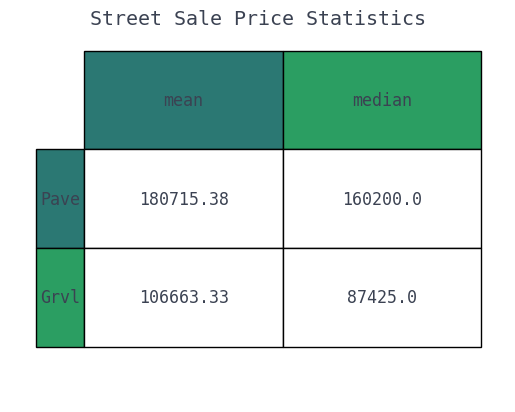

In [20]:
street_group_stats = fe_df.groupby("Street")["SalePrice"].agg(["mean", "median"]).sort_values(by="median", ascending=False).round(2)
street_group_colors = ["#2b7873", "#2b9e62"]

plt.table(cellText=street_group_stats.values, cellLoc="center", 
          rowLabels=street_group_stats.index, rowLoc="center", rowColours=street_group_colors,
          colLabels=street_group_stats.columns, colLoc="center", colColours=street_group_colors, 
          bbox=(0.15, 0.15, 0.8, 0.8))
plt.axis("off")
plt.title("Street Sale Price Statistics")
plt.show()

Does a different foundation make a difference in terms of sale price?

In [21]:
fe_df.groupby("Foundation").SalePrice.agg(["mean", "median", "count"]).sort_values(by="median", ascending=False)

,mean,median,count
Foundation,,,
PConc,226384.999234,208500.0,1305
Wood,180900.000000,164000.0,5
CBlock,148284.153537,140000.0,1244
BrkTil,128107.276527,123000.0,311
Stone,149786.818182,118000.0,11
Slab,110457.693878,103000.0,49


What about neighborhoods?

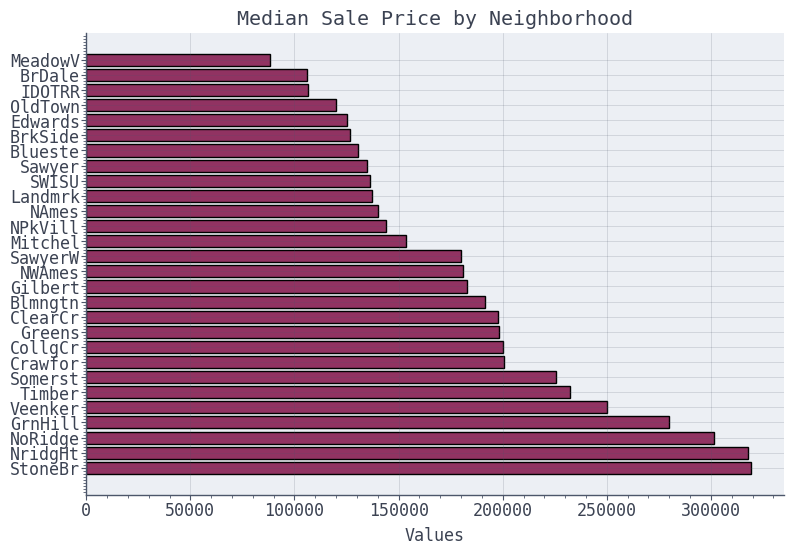

In [ ]:
neighborhood_df = fe_df.groupby("Neighborhood")["SalePrice"].median().sort_values(ascending=False)

plt.figure(figsize=(9, 6))
plt.barh(neighborhood_df.index, neighborhood_df.values, edgecolor="black", color="#913362")
plt.title("Median Sale Price by Neighborhood")
plt.xlabel("Values")
plt.show()

## Exploratory Data Analysis Conclusions

1.	Sale Price is positively skewed, indicating that while most homes sell between $100k and $250k, a relatively small number of expensive properties create a long right tail.
2.	Gross Living Area is positively skewed and exhibits an excess kurtosis of 1.07, suggesting somewhat heavier tails than a normal distribution and the presence of a few unusually large homes.
3.	The data suggests most houses were built and remodeled from ≈1950 to ≈2000. However, it is worth noting that some houses were built a long time ago, around ≈1860-1880, which represent outliers.
4.	Most houses are of average quality, ranging from 5 to 7, with only a few being of poor or high quality. The same happens with house condition. This is expected as not all houses are perfect/shabby.
5.	Higher house quality indicates opportunity to sell it at a higher sale price, according to the data. Furthermore, newer houses are sold for more compared to previous decades. However, houses in the 1920-1980 period were sold for roughly the same price as the ones in the 1880-1919 period, although there are some minor differences.
6.	Some of the most correlated numerical features with sale price are overall quality (0.8), overall basement surface (0.7) and gross living area (0.7).
7.	ANOVA is performed to test whether sale price means differ across sale conditions. The f-stat of 100.72 indicates that groups differ a lot and the p < 0.05 implies that the differences are statistically significant.
However, by using Tukey’s HSD, we can see that not all group means differ. Some null hypotheses aren’t to reject. For example, the mean difference between “Abnorml” and “Family” is $20.2k, meaning that “Family” mean is $20.2k higher than “Abnorml”. The p-adjusted value of 0.53 implies not to reject the null hypothesis of equal means.
8.	Group Analysis:
-	Houses with a paved street sell for more, on average, than ones of gravel street. The difference isn’t tiny: just to mention, the mean for the first category is $180715 vs. $106663 for the second one.
-	Homes with poured concrete foundations exhibit the highest average sale prices, although this relationship may partly reflect differences in age, size, and construction quality.
-	When looking at the median sale price by neighborhood, the top spot is taken by Stone Brook, with a median value of more than $300k. It is followed by Northridge Heights and Northridge.
Neighborhood appears to be a major driver of housing prices, with median sale prices ranging from approximately $88k in Meadow Village to $319k in Stone Brook.